In [1]:
import xarray as xr
import datetime
import pymannkendall as mk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# load landcover and anette's landcover! (first normal landcover)
land_cover = xr.open_dataset('/mnt/data7/nfs4/avh_ndvi/sdupuis/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7b.nc', engine='netcdf4')

In [3]:
lc = land_cover.sel(lat=slice(72,55), lon=slice(-168,-150))

In [4]:
yearly = xr.open_dataset('output_data/standard_anomalies_yamal_day_yearly_2.nc')

In [5]:
lc_downscaled = xr.open_dataset('lc_downscaled.nc', engine='netcdf4')

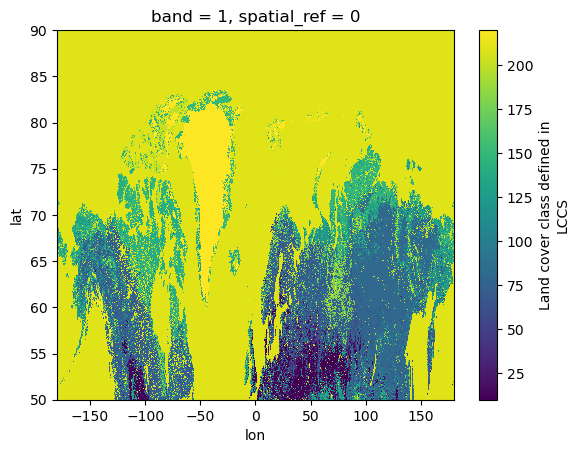

In [6]:
lc_downscaled['lccs_class'].plot();

In [7]:
#lc_interp = land_cover.interp(lat=yearly.coords['lat'], lon=yearly.coords['lon'], method='nearest')

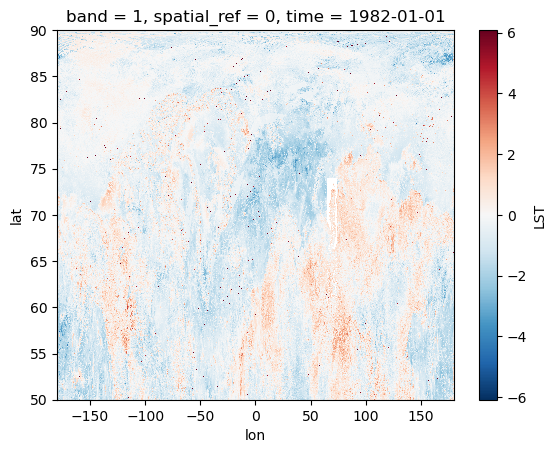

In [8]:
yearly['LST'].isel(time=1).plot();

In [9]:
subset = yearly.sel(lat=slice(55,72), lon=slice(-168,-150), time=slice('1982', '2018'))

In [10]:
yearly = yearly.where(lc_downscaled['lccs_class'] != 210)

In [11]:
# remove 1981 because not complete, verify 1988 and  1998 ! 

In [12]:
yearly_subset = yearly['LST'].sel( time=slice('1982', '2018'))

In [14]:
yearly_subset

<xarray.DataArray 'LST' (lat: 800, lon: 7200, time: 37)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lat          (lat) float32 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
    band         int64 1
    spatial_ref  int64 0
  * time         (time) datetime64[ns] 1982-01-01 1983-01-01 ... 2018-01-01

In [15]:

for_plots= yearly_subset.clip(min=-3, max=3)

da = for_plots.sel( time=slice("2001", "2018") )

In [16]:
bounds = [-3, -2, -1, 1, 2, 3]
colors = [
    "#08306b",  # dark blue
    "#4292c6",  # medium blue
    "#bdbdbd",  # grey
    "#fb6a4a",  # red
    "#cb181d",  # strong red
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)


/tmp/ipykernel_727/475828300.py:27: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax, t in zip(p.axes.flat, da["time"].values):
/tmp/ipykernel_727/475828300.py:31: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in p.axes.flat:


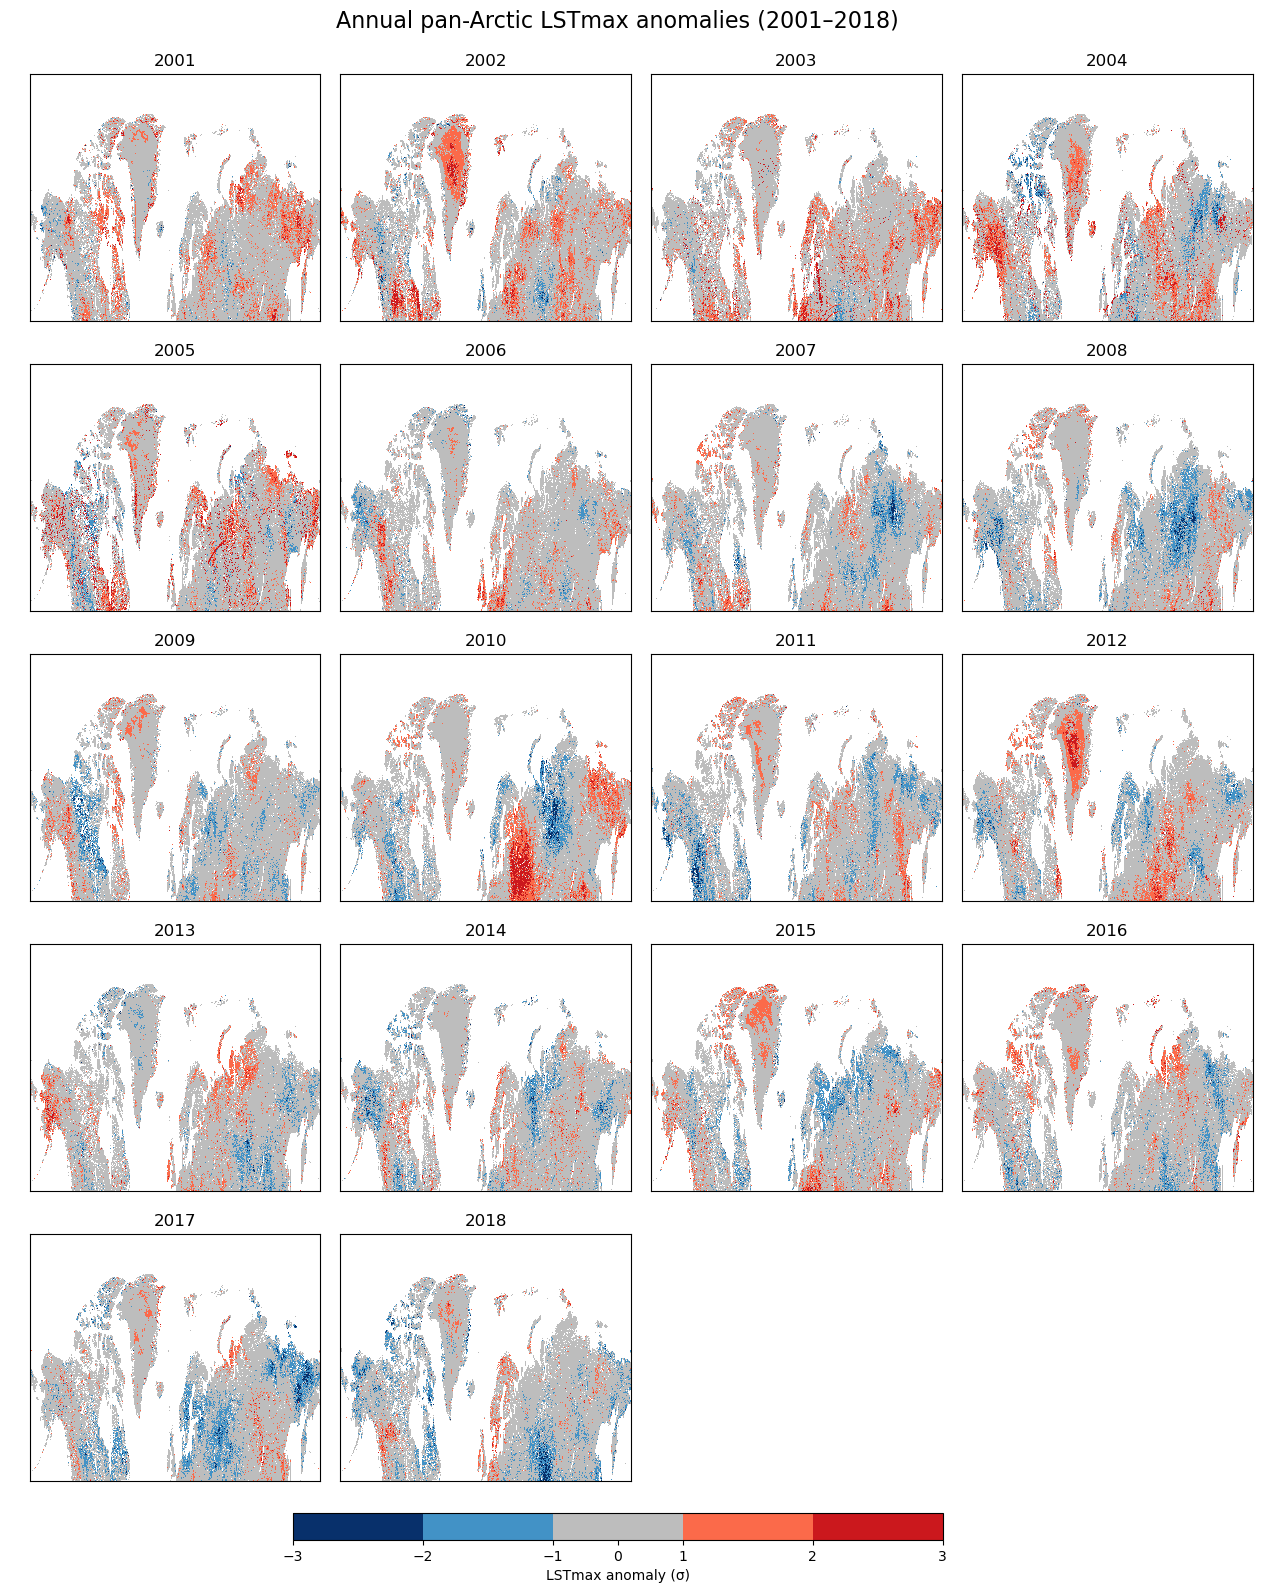

In [ ]:
p = da.plot(
    x="lon",
    y="lat",
    col="time",
    col_wrap=4,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

#cbar = p.fig.colorbar(
    #plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    #ax=p.axes,
    #orientation="horizontal",
    #fraction=0.025,
    #pad=0.08,
    #aspect=40  # makes it thinner
#)

# Super title
p.fig.suptitle(
    "Annual pan-Arctic LSTmax anomalies (2001–2018)",
    fontsize=16,
    y=1.02
)

for ax, t in zip(p.axes.flat, da["time"].values):
    year = str(t)[:4]
    ax.set_title(year)

for ax in p.axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(" ")
    ax.set_ylabel(" ")

# Create a custom axis for the colorbar
cax = p.fig.add_axes([0.25, 0.00, 0.5, 0.018])
# [left, bottom, width, height] in figure fraction

cbar = p.fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax,
    orientation="horizontal"
)



cbar.set_label("LSTmax anomaly (σ)")
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])




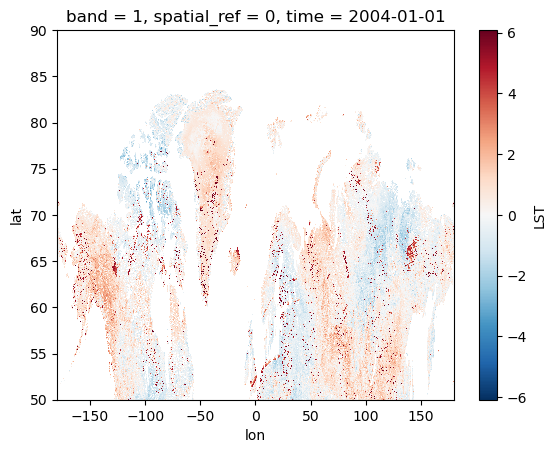

In [114]:
yearly['LST'].isel(time=23).plot();

In [14]:
subset

<xarray.Dataset>
Dimensions:      (lat: 340, lon: 360, time: 37)
Coordinates:
  * lat          (lat) float32 55.03 55.08 55.12 55.17 ... 71.88 71.93 71.97
  * lon          (lon) float32 -168.0 -167.9 -167.9 ... -150.1 -150.1 -150.0
    band         int64 ...
    spatial_ref  int64 ...
  * time         (time) datetime64[ns] 1982-01-01 1983-01-01 ... 2018-01-01
Data variables:
    LST          (lat, lon, time) float32 ...

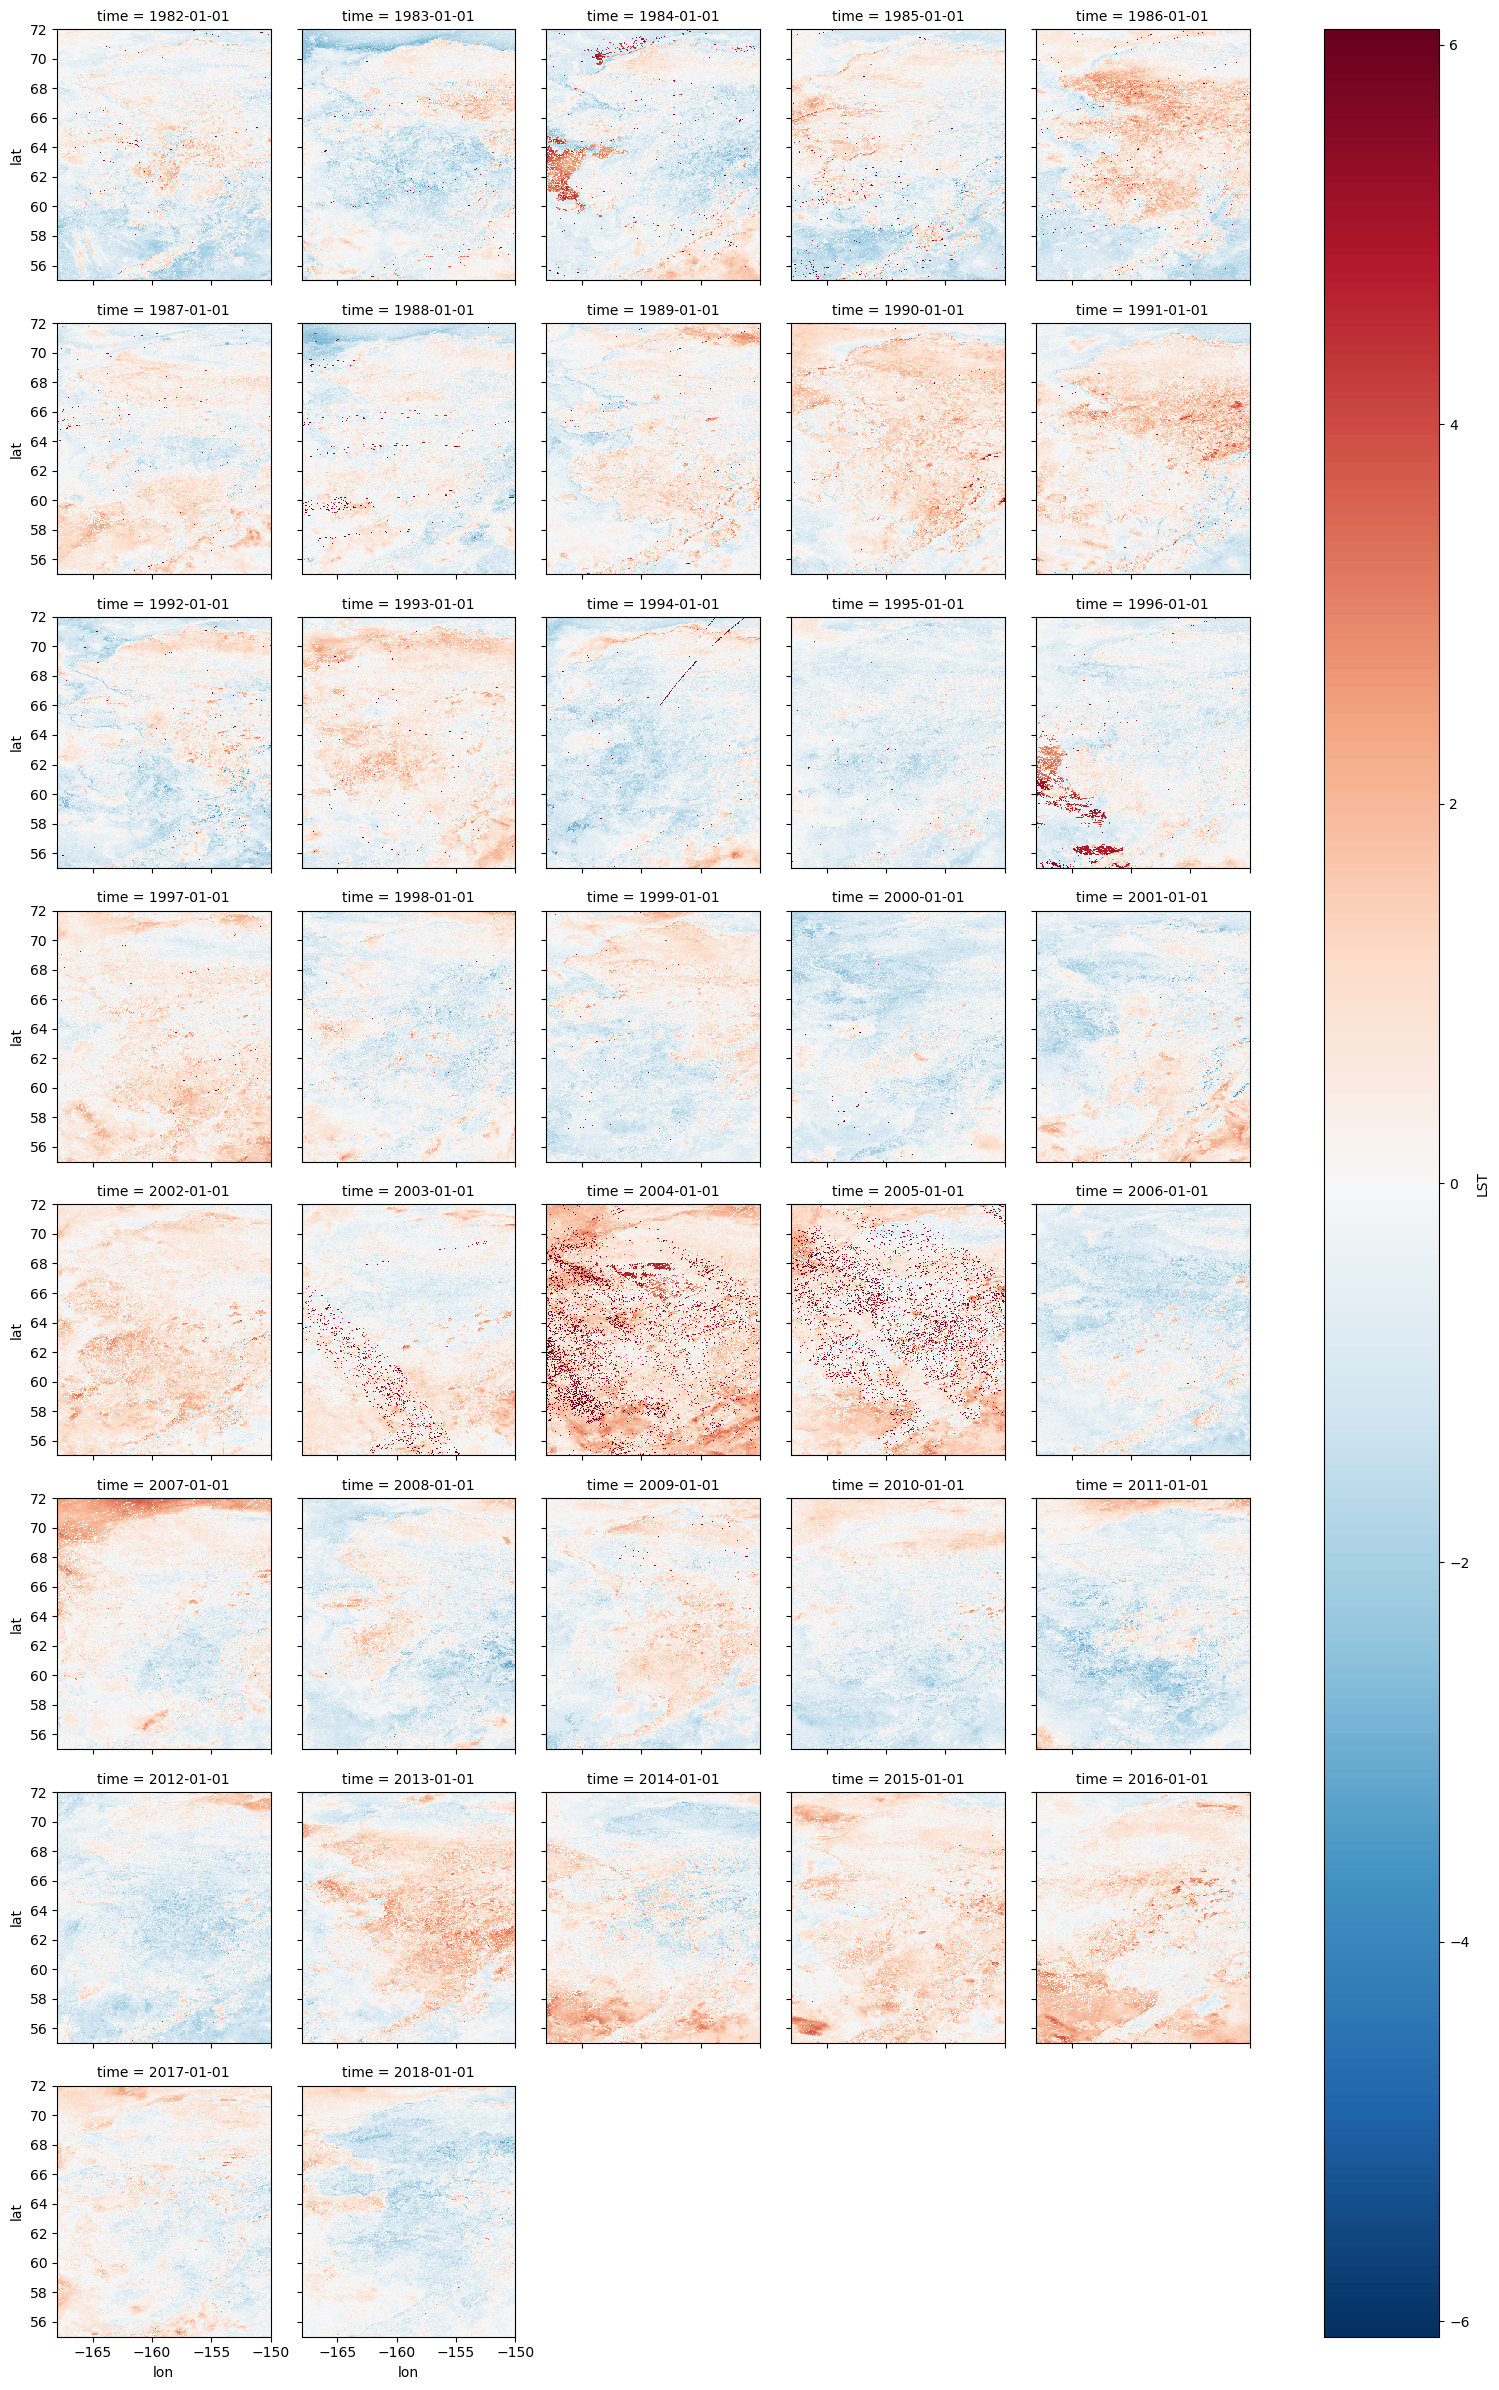

In [15]:
subset['LST'].sel(lat=slice(55,72), lon=slice(-168,-150), time=slice('1981','2018')).plot(x="lon", y="lat", col="time", col_wrap=5);

In [16]:
n_valid = yearly_subset.count(dim="time")

In [17]:
n_valid = n_valid.where(lc_downscaled['lccs_class'] != 210)

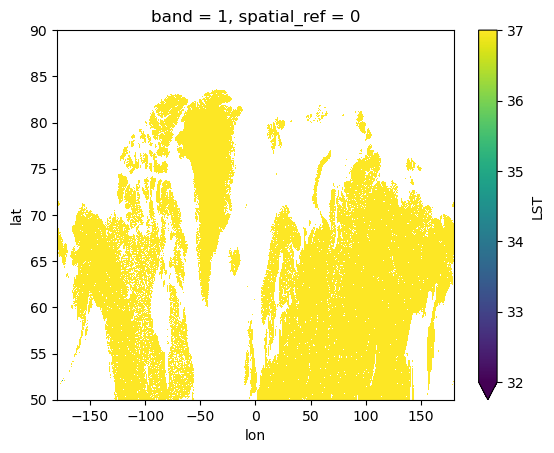

In [18]:
# save as plots
n_valid.plot(vmin=32);

In [19]:
above = ((yearly_subset > 0) & (yearly_subset < 3.0)).sum(dim="time")
below = ((yearly_subset < 0) & (yearly_subset > -3.0)).sum(dim="time")

In [20]:
below = below.where((lc_downscaled['lccs_class'] != 210) & (below!=0))
above = above.where((lc_downscaled['lccs_class'] != 210) & (above!=0))

In [21]:
above_1 = ((yearly_subset > 1) & (yearly_subset < 3.0)).sum(dim="time")
below_minus1 = ((yearly_subset < -1) & (yearly_subset > -3.0)).sum(dim="time")

In [22]:
below_minus1 = below_minus1.where((lc_downscaled['lccs_class'] != 210) & (below_minus1!=0))

In [23]:
above_1 = above_1.where((lc_downscaled['lccs_class'] != 210) & (above_1!=0))

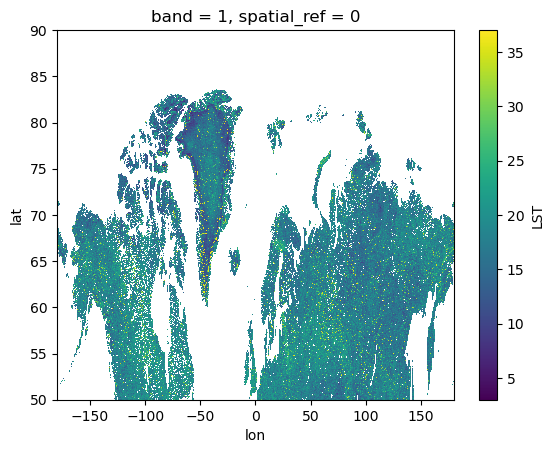

In [24]:
below.plot();

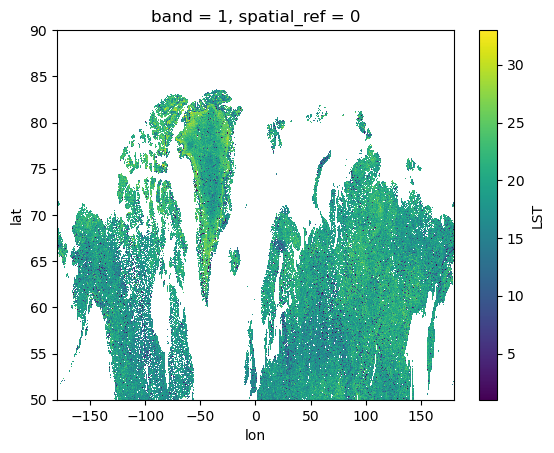

In [25]:
above.plot();

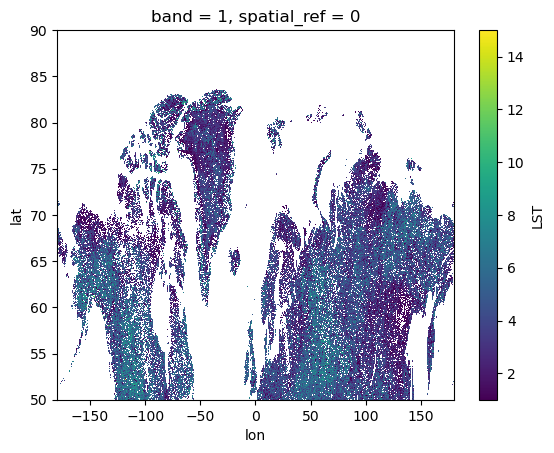

In [26]:
# anomalies above one
below_minus1.plot();

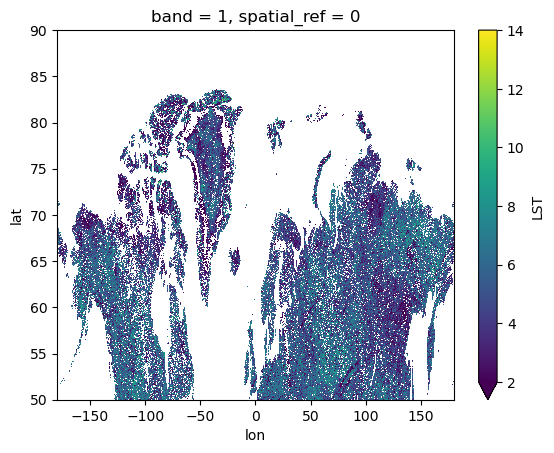

In [27]:
above_1.plot(vmin=2);

In [28]:
lst= yearly_subset

In [29]:
valid_pixels = lst.count(dim=("lat", "lon"))
above = ((lst > 0 )& (lst<3)).sum(dim=("lat", "lon"))
prop_above_1 = above

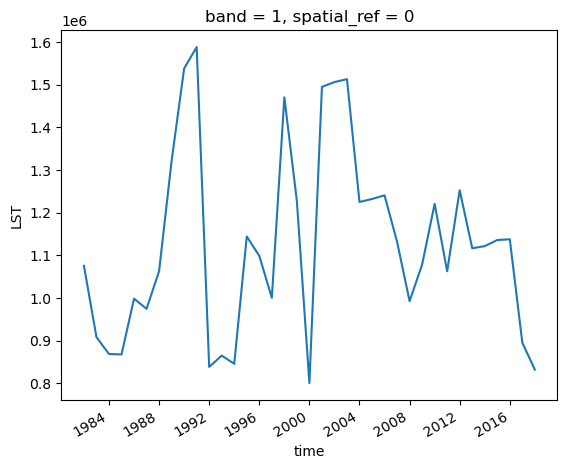

In [30]:
prop_above_1.plot();

In [31]:
import pymannkendall as mk

ts = prop_above_1.dropna(dim="time").values

In [32]:
result = mk.original_test(ts)

In [33]:
result

Mann_Kendall_Test(trend='no trend', h=False, p=0.5387479615505166, z=0.6147074157508847, Tau=0.07207207207207207, s=48.0, var_s=5846.0, slope=2066.271739130435, intercept=1079516.108695652)

In [73]:
# link to land cover
def prep_dataset(path):
    ds = xr.open_dataset(path)
    land_cover = xr.open_dataset('lc_downscaled.nc', engine='netcdf4')
    n_valid = ds['LST'].count(dim="time")
    n_valid = n_valid.where(land_cover['lccs_class'] != 210)
    above_1 = ((ds['LST'] > 1) & (ds['LST'] < 3.0)).sum(dim="time")
    below_minus1 = ((ds['LST'] < -1) & (ds['LST'] > -3.0)).sum(dim="time")
    below_minus1 = below_minus1.where(land_cover['lccs_class'] != 210)
    above_1 = above_1.where(land_cover['lccs_class'] != 210)


    return above_1, below_minus1


In [94]:
def map_landcover(df):

    lc_group_map = {
    # 1. Agriculture
    10: "Crop",
    11: "Crop",
    20: "Crop",
    30: "Crop",
    40: "Crop",

    # 2. Forest
    50: "EBF",
    60: "DBF", 61: "DBF", 62: "DBF",
    70: "ENF", 71: "ENF", 72: "ENF",
    80: "DNF", 81: "DNF", 82: "DNF",
    90: "MF",
    100: "MF",
    160: "FF",
    170: "FF",

    # 3. Grassland
    110: "Grass",
    130: "Grass",

    # 4. Wetland
    180: "Wet",

    # 5. Settlement
    190: "Urban",

    # 6. Other (Shrubland / Sparse / Bare / Water)
    120: "Shrub",
    121: "Shrub",
    122: "Shrub",
    140: "Lichens",
    150: "Sparse",
    151: "Sparse",
    152: "Sparse",
    153: "Sparse",
    200: "Bare",
    201: "Bare",
    202: "Bare",
    220: "Ice"
    }

    df["landcover_group"] = df["landcover"].map(lc_group_map)
    # filter classes with very low samples
    counts = df["landcover_group"].value_counts()
    print(counts)
    valid_classes = counts[counts > 20].index

    df = df[df["landcover_group"].isin(valid_classes)]
    return df


In [36]:
def map_kg(df):

    lc_group_map = {
    # 1. Agriculture
    1:"Af",
    2:"Am",
    3:"Aw",

    4:"Bwh",
    5:"Bwk",
    6:"BSh",
    7:"BSk",

    8: "Csa",
    9: "Csb",
    10:"Csc",

    11: "Cwa",
    12: "Cwb",
    13: "Cwc",

    14: "Cfa",
    15: "Cfb",
    16: "Cfc",

    17: "Dsa",
    18: "Dsb",
    19: "Dsc",
    20: "Dsd",


    21: "Dwa",
    22: "Dwb",
    23: "Dwc",
    24: "Dwd",
    25: "Dfa",
    26: "Dfb",
    27: "Dfc",
    28: "Dfd",
    30: "EF",
    29: "ET"
    }

    df["landcover_group"] = df["landcover"].map(lc_group_map)
    # filter classes with very low samples
    counts = df["landcover_group"].value_counts()
    print(counts)
    valid_classes = counts[counts > 20].index

    df = df[df["landcover_group"].isin(valid_classes)]
    return df


In [37]:
# link to land cover ? Day and Night -> check with air temperature
def df_creation_kg(ds):
    kg = xr.open_dataset('/mnt/data7/nfs4/avh_ndvi/sdupuis/koppen_geiger_0p5.tif').squeeze()
    kg_interp = kg.interp(y=ds['lat'], x=ds.coords['lon'], method='nearest')
    data = ds.where(~np.isnan(kg_interp['band_data']))
    landcover = kg_interp.where(~np.isnan(ds))
    trend_1d = data.stack(points=("lat", "lon"))
    lc_1d = landcover['band_data'].stack(points=("lat", "lon"))

    valid = (~np.isnan(trend_1d)) & (~np.isnan(lc_1d))
    trend_1d = trend_1d[valid]
    lc_1d = lc_1d[valid]
    df = pd.DataFrame({
    "trend": trend_1d.values,
    "landcover": lc_1d.values.astype(int)
    })

    df_filtered = map_kg(df)
    return df_filtered

In [95]:
# link to land cover ? Day and Night -> check with air temperature
def df_creation(ds):
    lc_interp = xr.open_dataset('lc_downscaled.nc', engine='netcdf4')
    data = ds.where(~np.isnan(lc_interp['lccs_class']))
    landcover = lc_interp.where(~np.isnan(ds))
    trend_1d = data.stack(points=("lat", "lon"))
    lc_1d = landcover['lccs_class'].stack(points=("lat", "lon"))

    valid = (~np.isnan(trend_1d)) & (~np.isnan(lc_1d))
    trend_1d = trend_1d[valid]
    lc_1d = lc_1d[valid]
    df = pd.DataFrame({
    "trend": trend_1d.values,
    "landcover": lc_1d.values.astype(int)
    })

    df_filtered = map_landcover(df)
    return df_filtered


In [96]:
above_anoms_d, below_anoms_d = prep_dataset('output_data/standard_anomalies_yamal_day_yearly_2.nc')

In [97]:
above_anoms_n, below_anoms_n = prep_dataset('output_data/standard_anomalies_yamal_NIGHT_yearly.nc')

In [98]:
anom_df_above1_d = df_creation(above_anoms_d)

landcover_group
ENF        374534
DNF        338694
Sparse     259449
Ice        257622
Crop       173648
MF         156258
Grass      136057
Lichens    131147
Shrub      119594
DBF         95905
Bare        92154
Wet         71170
FF          12958
Urban        5127
Name: count, dtype: int64


In [99]:
anom_df_below_d = df_creation(below_anoms_d)

landcover_group
ENF        374534
DNF        338694
Sparse     259449
Ice        257622
Crop       173648
MF         156258
Grass      136057
Lichens    131147
Shrub      119594
DBF         95905
Bare        92154
Wet         71170
FF          12958
Urban        5127
Name: count, dtype: int64


In [100]:
anom_df_above1_n = df_creation(above_anoms_n)
anom_df_below_n = df_creation(below_anoms_n)
result_anoms_alaska = (
    pd.concat(
        [anom_df_above1_d, anom_df_below_d, anom_df_above1_n, anom_df_below_n],
        keys=["Day_positive", "Day_negative", "Night_positive", "Night_negative"],
        names=["Datasets"]
    )
    .reset_index(level="Datasets")
)

landcover_group
ENF        374534
DNF        338694
Sparse     259449
Ice        257622
Crop       173648
MF         156258
Grass      136057
Lichens    131147
Shrub      119594
DBF         95905
Bare        92154
Wet         71170
FF          12958
Urban        5127
Name: count, dtype: int64
landcover_group
ENF        374534
DNF        338694
Sparse     259449
Ice        257622
Crop       173648
MF         156258
Grass      136057
Lichens    131147
Shrub      119594
DBF         95905
Bare        92154
Wet         71170
FF          12958
Urban        5127
Name: count, dtype: int64


In [61]:
kg_df_above1_n = df_creation_kg(above_anoms_n)
kg_df_below_n = df_creation_kg(below_anoms_n)
kg_df_below_d = df_creation_kg(below_anoms_d)
kg_df_above1_d = df_creation_kg(above_anoms_d)
result_anoms_kg = (
    pd.concat(
        [kg_df_above1_d, kg_df_below_d, kg_df_above1_n, kg_df_below_n],
        keys=["Day_positive", "Day_negative", "Night_positive", "Night_negative"],
        names=["Datasets"]
    )
    .reset_index(level="Datasets")
)

landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64
landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64
landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64
landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd 

In [65]:
counts = result_anoms_alaska["landcover_group"].value_counts()

In [66]:
counts

landcover_group
ENF           1498136
DNF           1354776
Sparse        1037796
Ice           1030488
Crop           694592
MF             625032
Grass          544228
Lichens        524588
Shrub          478376
DBF            383620
Bare           368616
Wet            284680
FF              51832
Settlement      20508
Name: count, dtype: int64

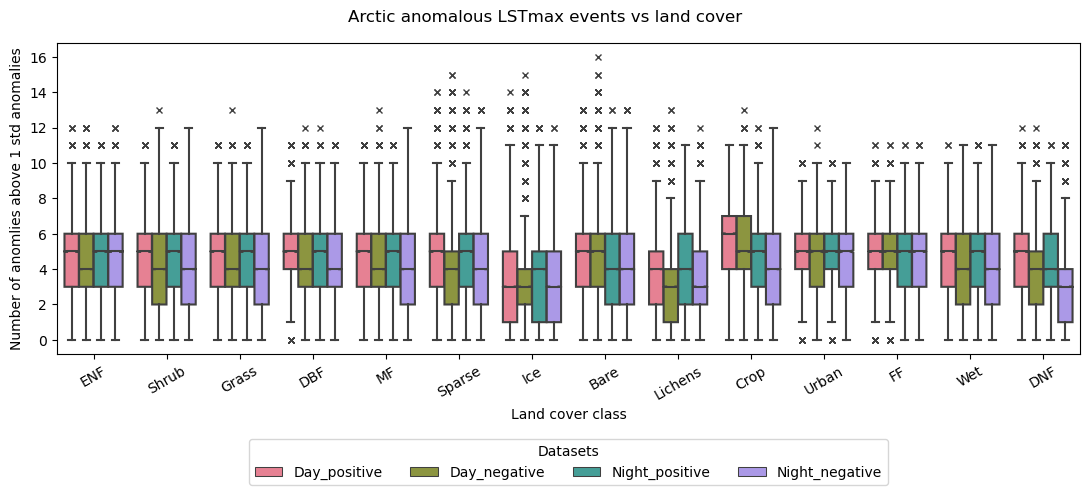

In [101]:
# Group all boxplots
plt.figure(figsize=(11, 6))
ax= sns.boxplot(
    data=result_anoms_alaska,
    x="landcover_group",   # or "landcover"
    y="trend",
    hue='Datasets',
    palette = 'husl',
    flierprops={"marker":"x"},
    notch=True
)

plt.ylabel("Number of anomlies above 1 std anomalies")
plt.xlabel("Land cover class")
plt.suptitle('Arctic anomalous LSTmax events vs land cover')
plt.xticks(rotation=30)
ax.legend(
    title="Datasets",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=len(result_anoms_alaska["Datasets"].unique()),
    frameon=True
    
)
plt.tight_layout(rect=[0, 0.1, 1, 1])


plt.savefig('Arctic_box_plot_anomalies_all.png')
plt.show()

In [67]:
counts = result_anoms_kg["landcover_group"].value_counts()

In [68]:
counts

landcover_group
Dfc    3888532
ET     1498728
Dfb    1219536
EF      864468
Dwc     487908
Dsc     371500
BSk     173552
Cfb     170248
Dwb      89336
Dwd      74464
Dfd      35892
Dfa      10512
Cfc       3512
Dsd       2352
Dsb       1724
Bwk       1064
Name: count, dtype: int64

In [69]:
result_anoms_kg

,Datasets,trend,landcover,landcover_group
0,Day_positive,5.0,15,Cfb
1,Day_positive,6.0,15,Cfb
2,Day_positive,5.0,15,Cfb
3,Day_positive,0.0,15,Cfb
4,Day_positive,0.0,15,Cfb
...,...,...,...,...
2223327,Night_negative,8.0,29,ET
2223328,Night_negative,4.0,29,ET
2223329,Night_negative,7.0,29,ET
2223330,Night_negative,9.0,29,ET


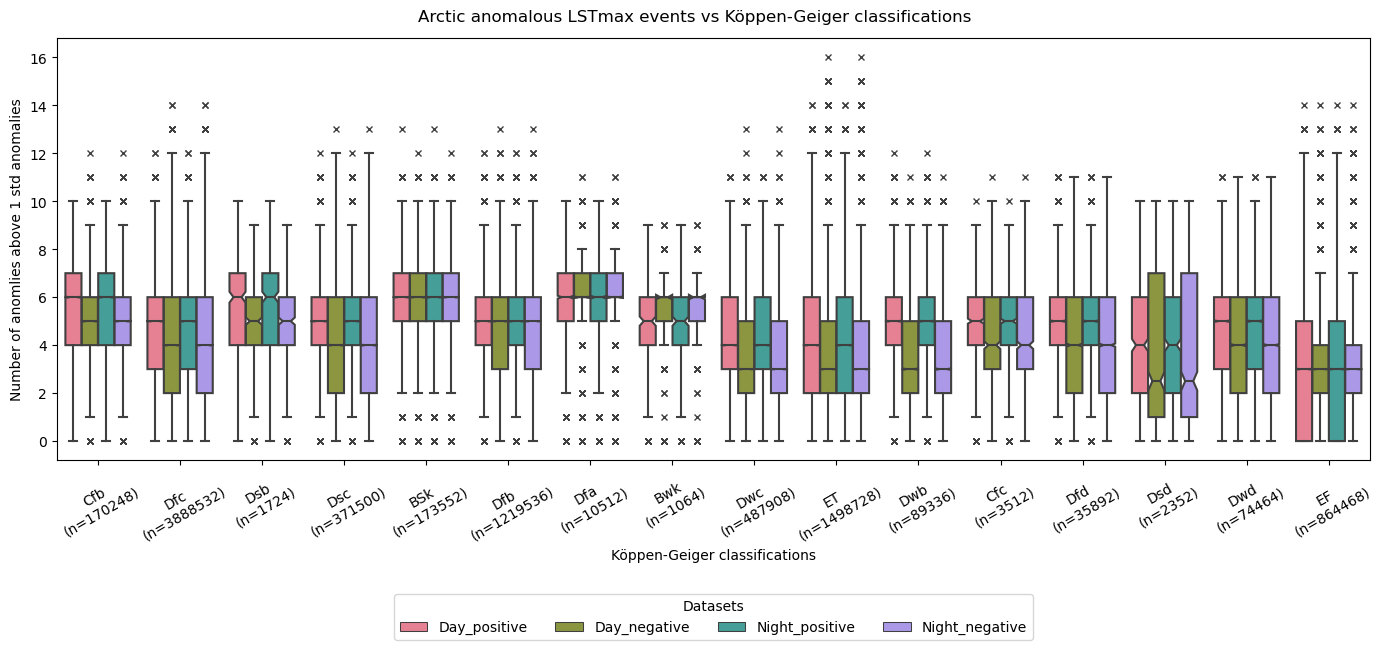

In [80]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(
    data=result_anoms_kg,
    x="landcover_group",
    y="trend",
    hue="Datasets",
    palette="husl",
    flierprops={"marker": "x"},
    notch=True
)
ax.legend(
    title="Datasets",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=len(result_anoms_kg["Datasets"].unique()),
    frameon=True
)

order = [tick.get_text() for tick in ax.get_xticklabels()]

new_labels = [
    f"{cat}\n(n={counts[cat]})" for cat in order
]

ax.set_xticklabels(new_labels, rotation=30)
plt.ylabel("Number of anomlies above 1 std anomalies")
plt.xlabel("Köppen-Geiger classifications")
plt.suptitle('Arctic anomalous LSTmax events vs Köppen-Geiger classifications')
# Make room for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])

#plt.savefig("Arctic_box_plot_anomalies_all_kg.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# do trends of anomalies but not standardized! -> should  be the same -> how trends relate to anomalies ?? 

In [ ]:
# try with annette's landcover!

In [74]:
# koppen geiger zones
koppen = xr.open_dataset('/mnt/data7/nfs4/avh_ndvi/sdupuis/koppen_geiger_0p5.tif')

In [75]:
koppen

<xarray.Dataset>
Dimensions:      (band: 1, x: 720, y: 360)
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * y            (y) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
    spatial_ref  int64 ...
Data variables:
    band_data    (band, y, x) float32 ...

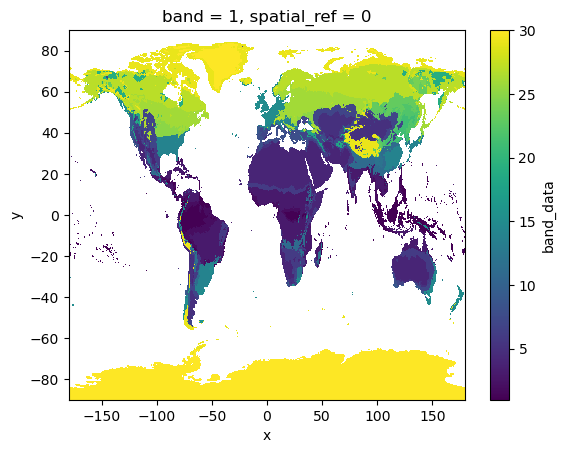

In [76]:
koppen['band_data'].plot();

In [77]:
kg_df_above1_d = df_creation_kg(above_anoms_d)
kg_df_below1_d = df_creation_kg(below_anoms_d)


landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64
landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64


In [78]:
kg_df_above1_n = df_creation_kg(above_anoms_d)
kg_df_below_n = df_creation_kg(below_anoms_d)
result_anoms_kg = (
    pd.concat(
        [kg_df_above1_d, kg_df_below1_d, kg_df_above1_n, kg_df_below_n],
        keys=["Day_positive", "Day_negative", "Night_positive", "Night_negative"],
        names=["Datasets"]
    )
    .reset_index(level="Datasets")
)

landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64
landcover_group
Dfc    972133
ET     374682
Dfb    304884
EF     216117
Dwc    121977
Dsc     92875
BSk     43388
Cfb     42562
Dwb     22334
Dwd     18616
Dfd      8973
Dfa      2628
Cfc       878
Dsd       588
Dsb       431
Bwk       266
Name: count, dtype: int64


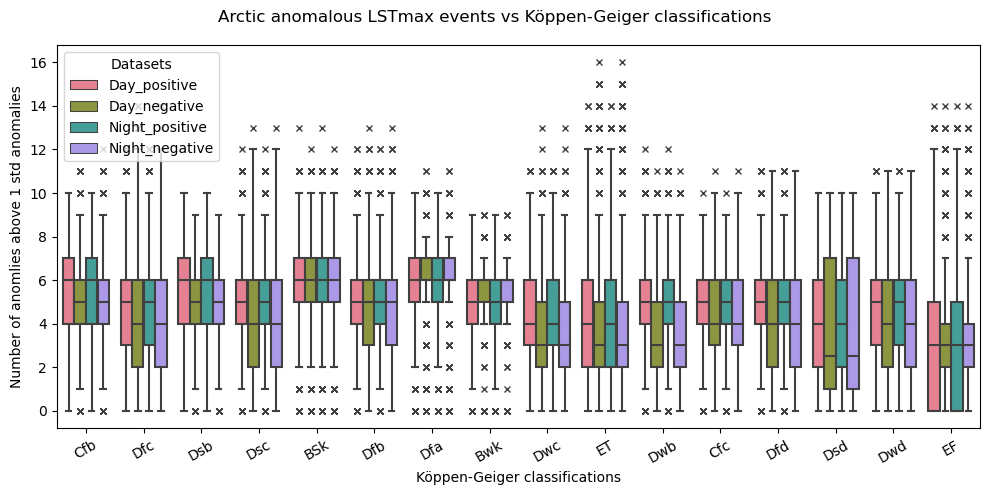

In [79]:
# Group all boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=result_anoms_kg,
    x="landcover_group",   # or "landcover"
    y="trend",
    hue='Datasets',
    palette = 'husl',
    flierprops={"marker":"x"}
)


plt.ylabel("Number of anomlies above 1 std anomalies")
plt.xlabel("Köppen-Geiger classifications")
plt.suptitle('Arctic anomalous LSTmax events vs Köppen-Geiger classifications')
plt.xticks(rotation=30)
plt.tight_layout()
#plt.savefig('Arctic_box_plot_anomalies_all_kg.png')
plt.show()

In [143]:
result_anoms_kg

,Datasets,trend,landcover,landcover_group
0,Day_positive,5.0,15,Cfb
1,Day_positive,6.0,15,Cfb
2,Day_positive,5.0,15,Cfb
3,Day_positive,0.0,15,Cfb
4,Day_positive,0.0,15,Cfb
...,...,...,...,...
2223327,Night_negative,7.0,29,ET
2223328,Night_negative,7.0,29,ET
2223329,Night_negative,9.0,29,ET
2223330,Night_negative,6.0,29,ET


In [89]:
order_kg = sorted(result_anoms_kg["landcover_group"].unique())

In [106]:
order_kg

['BSk',
 'Bwk',
 'Cfb',
 'Cfc',
 'Dfa',
 'Dfb',
 'Dfc',
 'Dfd',
 'Dsb',
 'Dsc',
 'Dsd',
 'Dwb',
 'Dwc',
 'Dwd',
 'EF',
 'ET']

In [110]:
order_landcover = [
    "Crop",
    "DBF",
    "ENF",
    "DNF",
    "MF",
    "Shrub",
    "Grass",
    "Lichens",
    "Sparse",
    "FF",
    "Wet",
    "Urban",
    "Bare",
    "Ice"
]


In [111]:
order_landcover

['Crop',
 'DBF',
 'ENF',
 'DNF',
 'MF',
 'Shrub',
 'Grass',
 'Lichens',
 'Sparse',
 'FF',
 'Wet',
 'Urban',
 'Bare',
 'Ice']

In [105]:
result_anoms_alaska

,Datasets,trend,landcover,landcover_group
0,Day_positive,5.0,70,ENF
1,Day_positive,6.0,71,ENF
2,Day_positive,5.0,71,ENF
3,Day_positive,0.0,71,ENF
4,Day_positive,0.0,71,ENF
...,...,...,...,...
2224410,Night_negative,8.0,150,Sparse
2224411,Night_negative,4.0,150,Sparse
2224412,Night_negative,7.0,150,Sparse
2224413,Night_negative,9.0,150,Sparse


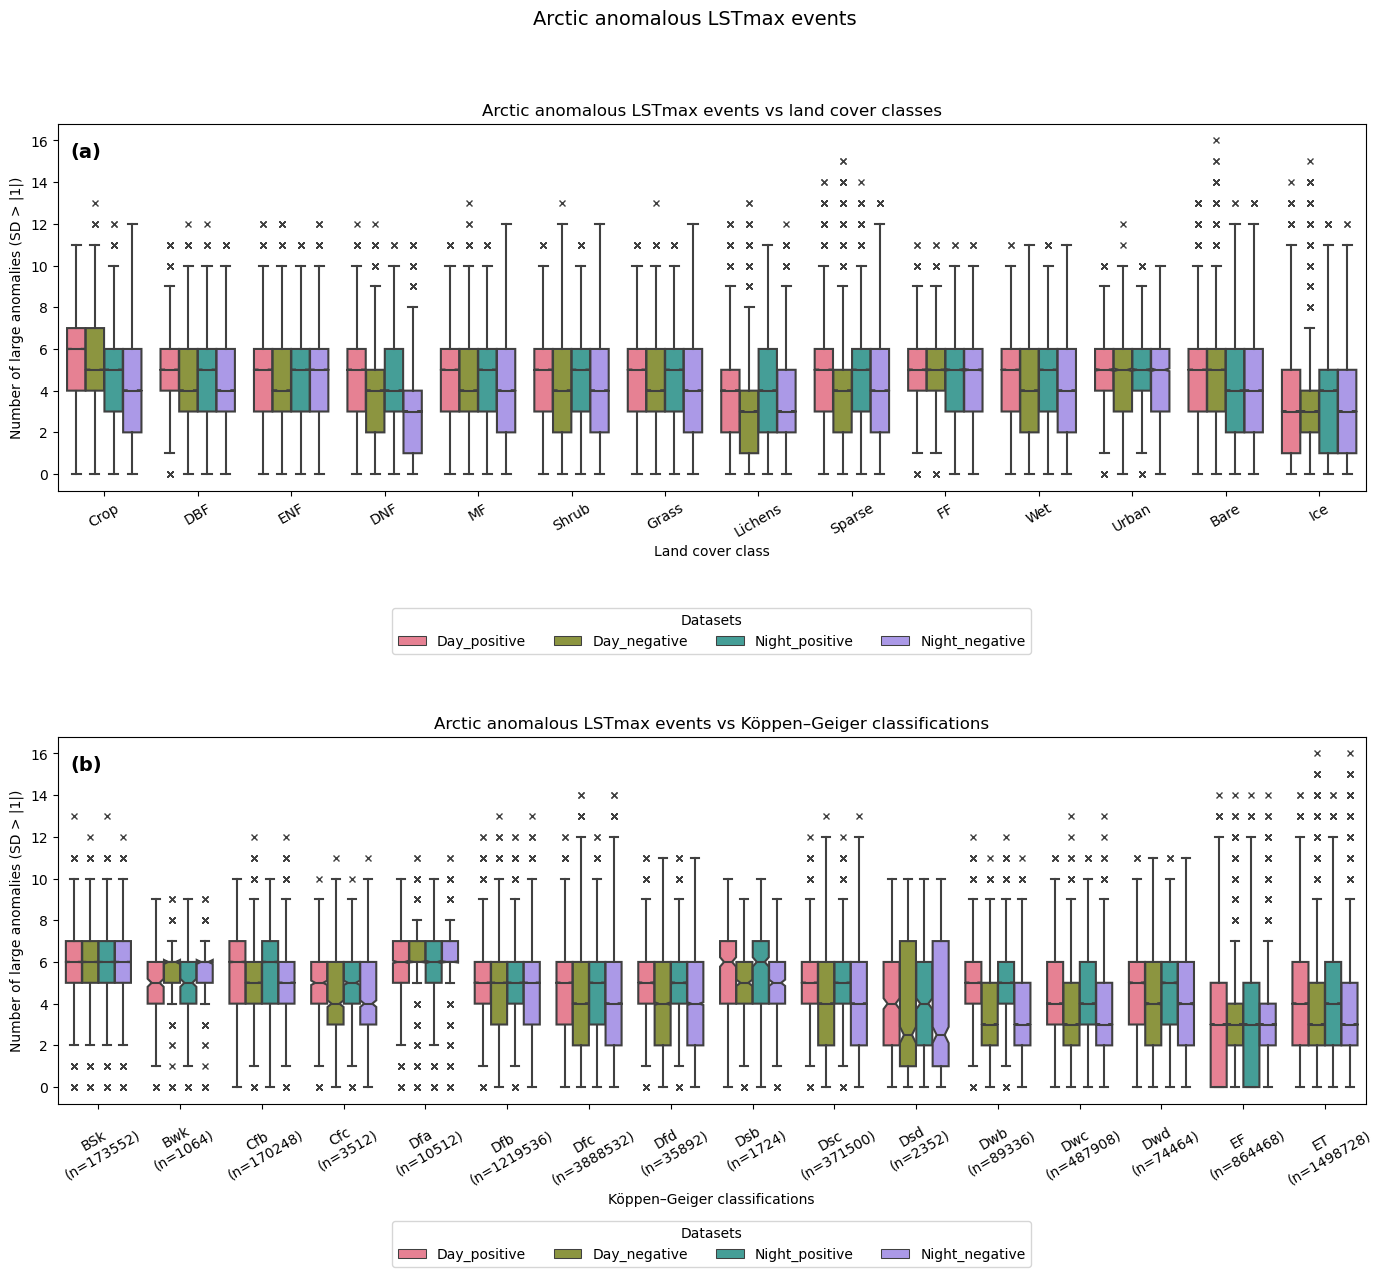

In [113]:
# subplots


fig, axes = plt.subplots(2, 1, figsize=(14, 15), sharey=True)

# =======================
# Subplot 1: Land cover
# =======================
ax = axes[0]
sns.boxplot(
    data=result_anoms_alaska,
    x="landcover_group",
    y="trend",
    hue="Datasets",
    palette="husl",
    flierprops={"marker": "x"},
    notch=True,
    order=order_landcover,
    ax=ax
)

axes[0].text(
    0.01, 0.95, "(a)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

ax.set_ylabel("Number of large anomalies (SD > |1|)")
ax.set_xlabel("Land cover class")
ax.set_title("Arctic anomalous LSTmax events vs land cover classes")
ax.tick_params(axis="x", rotation=30)

ax.legend(
    title="Datasets",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=len(result_anoms_alaska["Datasets"].unique()),
    frameon=True
)

# =======================
# Subplot 2: Köppen–Geiger
# =======================
ax = axes[1]
sns.boxplot(
    data=result_anoms_kg,
    x="landcover_group",
    y="trend",
    hue="Datasets",
    palette="husl",
    flierprops={"marker": "x"},
    notch=True,
    order=order_kg,
    ax=ax
)
axes[1].text(
    0.01, 0.95, "(b)",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

ax.set_xlabel("Köppen–Geiger classifications")
ax.set_ylabel("Number of large anomalies (SD > |1|)")
ax.set_title("Arctic anomalous LSTmax events vs Köppen–Geiger classifications")
ax.tick_params(axis="x", rotation=30)

# Update x-tick labels with counts
order = [tick.get_text() for tick in ax.get_xticklabels()]
new_labels = [f"{cat}\n(n={counts[cat]})" for cat in order]
ax.set_xticklabels(new_labels)

ax.legend(
    title="Datasets",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=len(result_anoms_kg["Datasets"].unique()),
    frameon=True
)

# =======================
# Final layout
# =======================
fig.suptitle("Arctic anomalous LSTmax events", fontsize=14)
fig.tight_layout(rect=[0, 0.1, 1, 0.95])

# Optional save
fig.savefig("Arctic_boxplots_combined.png", dpi=300, bbox_inches="tight")
fig.savefig("Arctic_boxplots_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

